# Entrega Group B

Notebook simple para analizar el agente de Group B sin depender de `analyze_training.py`.

Este notebook usa solo estos archivos:
- `experiment_results.csv` si existe,
- `q_memory_comparison.csv` para comparar entrenar desde 0 vs guardar `Q-values`.


In [14]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline", force=True)
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


def find_first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


cwd = Path.cwd()
experiment_csv = find_first_existing([
    cwd / "groups" / "Group B" / "artifacts" / "experiment_results.csv",
    cwd / "artifacts" / "experiment_results.csv",
])
memory_csv = find_first_existing([
    cwd / "groups" / "Group B" / "artifacts" / "q_memory_comparison.csv",
    cwd / "artifacts" / "q_memory_comparison.csv",
])

print("experiment_results.csv ->", experiment_csv.resolve() if experiment_csv else "no encontrado")
print("q_memory_comparison.csv ->", memory_csv.resolve() if memory_csv else "no encontrado")


experiment_results.csv -> C:\Users\tabut\OneDrive\Escritorio\Fundamentos de IA\Proyecto-Final\Connect4RL\groups\Group B\artifacts\experiment_results.csv
q_memory_comparison.csv -> C:\Users\tabut\OneDrive\Escritorio\Fundamentos de IA\Proyecto-Final\Connect4RL\groups\Group B\artifacts\q_memory_comparison.csv


## 1. Resultados de experimentos del agente actual

Esta seccion solo corre si existe `experiment_results.csv`.


In [15]:
if experiment_csv is not None:
    experiments_df = pd.read_csv(experiment_csv)
    display(experiments_df)
else:
    experiments_df = pd.DataFrame()
    print("No existe experiment_results.csv. Para generarlo corre run_experiments.py")


,experiment_id,label,model_path,opponent,games,wins,losses,draws,win_rate,loss_rate,draw_rate,stored_states,episodes_trained,sources_random,sources_self,num_phases,total_episodes,phase_plan
0,exp_random_5k_eps020,random_only_5000_eps_0.20,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Random,40,40,0,0,1.000,0.000,0.0,127741,5000,5000,0,1,5000,phase1:random:5000@eps=0.2
1,exp_random_5k_eps020,random_only_5000_eps_0.20,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Self,40,20,20,0,0.500,0.500,0.0,127741,5000,5000,0,1,5000,phase1:random:5000@eps=0.2
2,exp_random_10k_eps020,random_only_10000_eps_0.20,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Random,40,39,1,0,0.975,0.025,0.0,235372,10000,10000,0,1,10000,phase1:random:10000@eps=0.2
3,exp_random_10k_eps020,random_only_10000_eps_0.20,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Self,40,20,20,0,0.500,0.500,0.0,235372,10000,10000,0,1,10000,phase1:random:10000@eps=0.2
4,exp_self_10k_eps020,self_only_10000_eps_0.20,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Random,40,38,2,0,0.950,0.050,0.0,571866,10000,0,10000,1,10000,phase1:self:10000@eps=0.2
5,exp_self_10k_eps020,self_only_10000_eps_0.20,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Self,40,20,20,0,0.500,0.500,0.0,571866,10000,0,10000,1,10000,phase1:self:10000@eps=0.2
6,exp_self_20k_eps010,self_only_20000_eps_0.10,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Random,40,39,1,0,0.975,0.025,0.0,855834,20000,0,20000,1,20000,phase1:self:20000@eps=0.1
7,exp_self_20k_eps010,self_only_20000_eps_0.10,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Self,40,0,0,40,0.000,0.000,1.0,855834,20000,0,20000,1,20000,phase1:self:20000@eps=0.1
8,exp_mixed_8k_12k,random_8000_then_self_12000,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Random,40,40,0,0,1.000,0.000,0.0,784557,20000,8000,12000,2,20000,phase1:random:8000@eps=0.2 | phase2:self:12000...
9,exp_mixed_8k_12k,random_8000_then_self_12000,C:\Users\tabut\OneDrive\Escritorio\Fundamentos...,Self,40,20,20,0,0.500,0.500,0.0,784557,20000,8000,12000,2,20000,phase1:random:8000@eps=0.2 | phase2:self:12000...


In [16]:
if not experiments_df.empty:
    display(
        experiments_df[["label", "opponent", "win_rate", "draw_rate", "loss_rate", "total_episodes", "phase_plan"]].sort_values(
            ["label", "opponent"]
        )
    )
else:
    print("No hay datos de experiment_results.csv para mostrar")


,label,opponent,win_rate,draw_rate,loss_rate,total_episodes,phase_plan
8,random_8000_then_self_12000,Random,1.000,0.0,0.000,20000,phase1:random:8000@eps=0.2 | phase2:self:12000...
9,random_8000_then_self_12000,Self,0.500,0.0,0.500,20000,phase1:random:8000@eps=0.2 | phase2:self:12000...
10,random_8000_then_self_12000_then_self_8000,Random,1.000,0.0,0.000,28000,phase1:random:8000@eps=0.2 | phase2:self:12000...
11,random_8000_then_self_12000_then_self_8000,Self,0.500,0.0,0.500,28000,phase1:random:8000@eps=0.2 | phase2:self:12000...
2,random_only_10000_eps_0.20,Random,0.975,0.0,0.025,10000,phase1:random:10000@eps=0.2
3,random_only_10000_eps_0.20,Self,0.500,0.0,0.500,10000,phase1:random:10000@eps=0.2
0,random_only_5000_eps_0.20,Random,1.000,0.0,0.000,5000,phase1:random:5000@eps=0.2
1,random_only_5000_eps_0.20,Self,0.500,0.0,0.500,5000,phase1:random:5000@eps=0.2
4,self_only_10000_eps_0.20,Random,0.950,0.0,0.050,10000,phase1:self:10000@eps=0.2
5,self_only_10000_eps_0.20,Self,0.500,0.0,0.500,10000,phase1:self:10000@eps=0.2


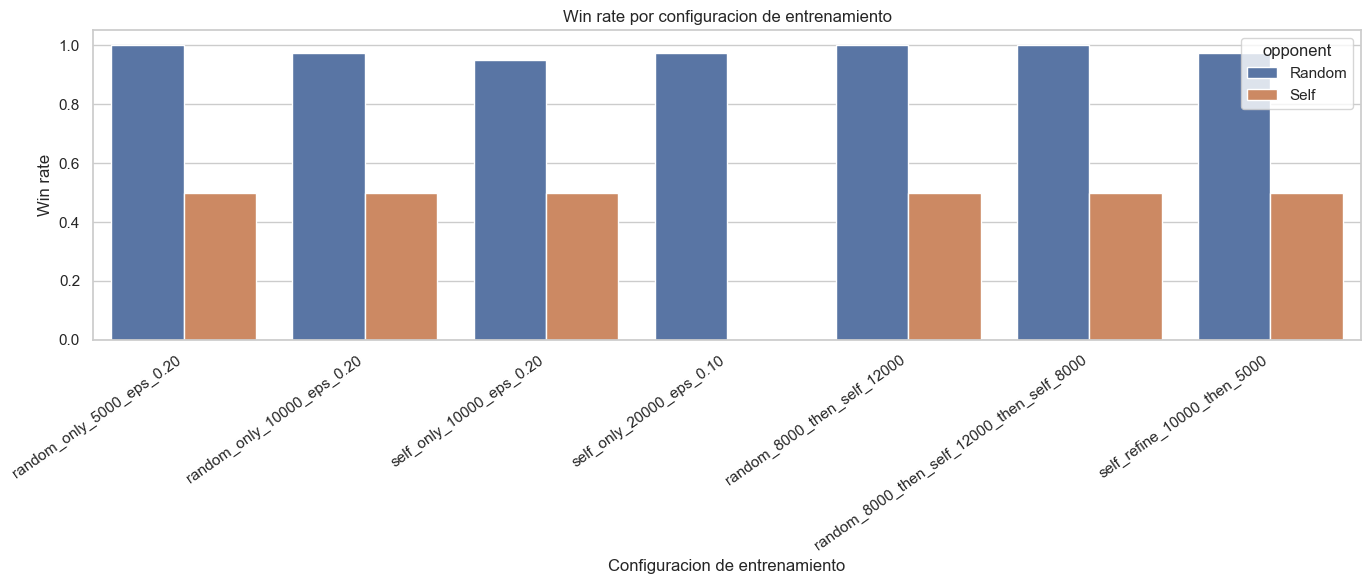

In [17]:
if not experiments_df.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(data=experiments_df, x="label", y="win_rate", hue="opponent")
    plt.title("Win rate por configuracion de entrenamiento")
    plt.xlabel("Configuracion de entrenamiento")
    plt.ylabel("Win rate")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Grafica omitida porque no existe experiment_results.csv")


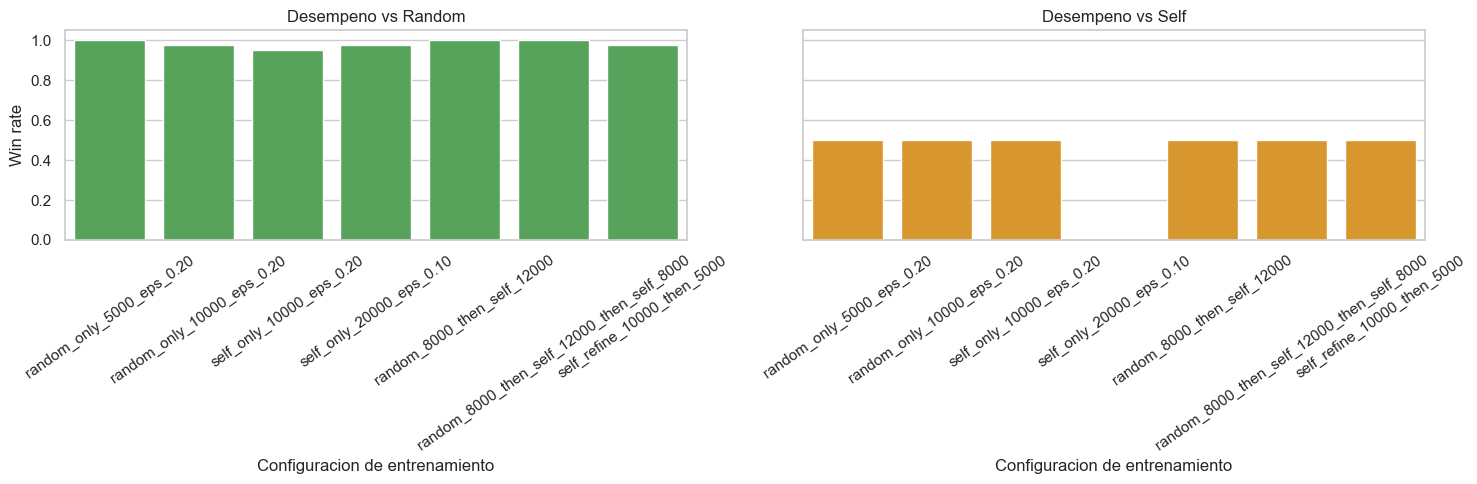

In [18]:
if not experiments_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for ax, opponent, color in zip(axes, ["Random", "Self"], ["#4CAF50", "#F39C12"]):
        subset = experiments_df[experiments_df["opponent"] == opponent].copy()
        sns.barplot(data=subset, x="label", y="win_rate", color=color, ax=ax)
        ax.set_title(f"Desempeno vs {opponent}")
        ax.set_xlabel("Configuracion de entrenamiento")
        ax.set_ylabel("Win rate")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()
else:
    print("Grafica omitida porque no existe experiment_results.csv")


## 2. Entrenamiento contra Random vs Self

Esta grafica compara configuraciones entrenadas solo contra `Random` y solo contra `Self`.


In [19]:
if not experiments_df.empty:
    compare_df = experiments_df[experiments_df["label"].isin([
        "random_only_5000_eps_0.20",
        "random_only_10000_eps_0.20",
        "self_only_10000_eps_0.20",
        "self_only_20000_eps_0.10",
    ])].copy()
    compare_df["training_type"] = compare_df["label"].apply(
        lambda x: "random_training" if x.startswith("random_only") else "self_training"
    )
    display(compare_df[["label", "training_type", "opponent", "win_rate", "draw_rate", "total_episodes"]].sort_values(
        ["training_type", "label", "opponent"]
    ))
else:
    compare_df = pd.DataFrame()
    print("Comparacion omitida porque no existe experiment_results.csv")


,label,training_type,opponent,win_rate,draw_rate,total_episodes
2,random_only_10000_eps_0.20,random_training,Random,0.975,0.0,10000
3,random_only_10000_eps_0.20,random_training,Self,0.500,0.0,10000
0,random_only_5000_eps_0.20,random_training,Random,1.000,0.0,5000
1,random_only_5000_eps_0.20,random_training,Self,0.500,0.0,5000
4,self_only_10000_eps_0.20,self_training,Random,0.950,0.0,10000
5,self_only_10000_eps_0.20,self_training,Self,0.500,0.0,10000
6,self_only_20000_eps_0.10,self_training,Random,0.975,0.0,20000
7,self_only_20000_eps_0.10,self_training,Self,0.000,1.0,20000


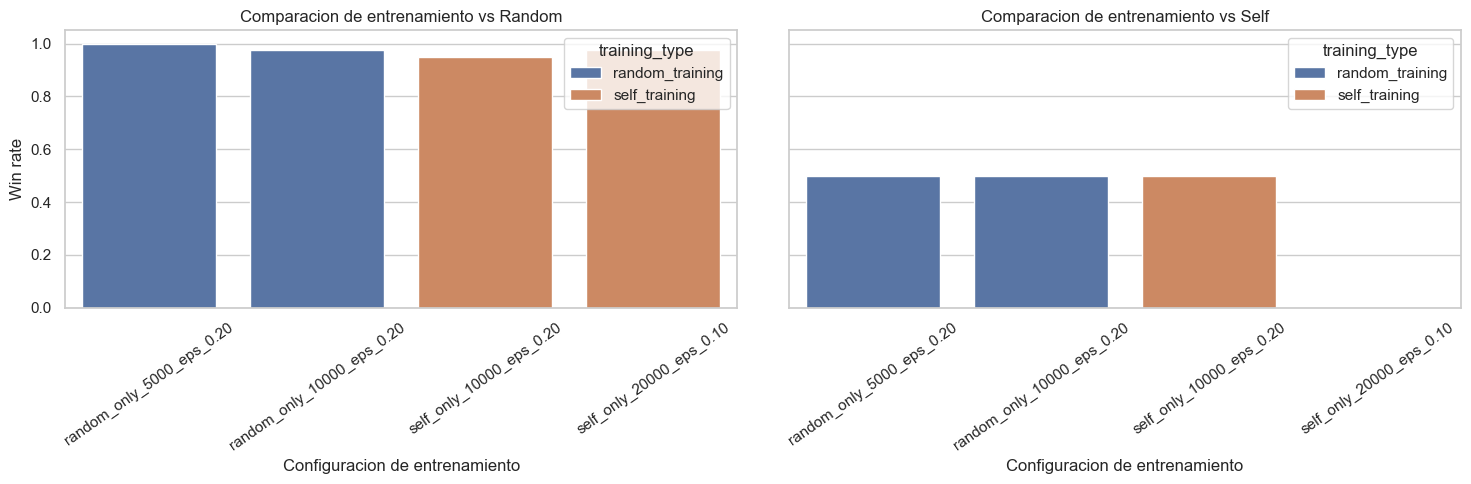

In [20]:
if not compare_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
    for ax, opponent in zip(axes, ["Random", "Self"]):
        subset = compare_df[compare_df["opponent"] == opponent].copy()
        sns.barplot(data=subset, x="label", y="win_rate", hue="training_type", ax=ax)
        ax.set_title(f"Comparacion de entrenamiento vs {opponent}")
        ax.set_xlabel("Configuracion de entrenamiento")
        ax.set_ylabel("Win rate")
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()
else:
    print("Grafica omitida porque no existe experiment_results.csv")


## 3. Desde cero vs guardando Q-values

Esta es la comparacion correcta para medir si guardar memoria ayuda.

- `from_scratch`: cada punto entrena un agente nuevo desde 0.
- `incremental_q_memory`: el agente entrena, guarda `Q-values`, recarga y sigue entrenando.


In [21]:
from IPython.display import display


def _find_first_existing_local(paths):
    for path in paths:
        if path.exists():
            return path
    return None


current_memory_csv = globals().get("memory_csv")
if current_memory_csv is None:
    current_cwd = Path.cwd()
    current_memory_csv = _find_first_existing_local([
        current_cwd / "groups" / "Group B" / "artifacts" / "q_memory_comparison.csv",
        current_cwd / "artifacts" / "q_memory_comparison.csv",
    ])

if current_memory_csv is not None:
    memory_df = pd.read_csv(current_memory_csv)
    memory_df["modelo"] = memory_df["strategy"].map({
        "from_scratch": "Entrena desde 0",
        "incremental_q_memory": "Guarda Q-values",
    })
    display(memory_df)
else:
    memory_df = pd.DataFrame()
    print("No existe q_memory_comparison.csv. Para generarlo corre compare_q_memory.py")


,strategy,episodes,train_mode,train_epsilon,opponent,games,wins,losses,draws,win_rate,loss_rate,draw_rate,stored_states,modelo
0,from_scratch,1000,random,0.2,Random,100,98,2,0,0.98,0.02,0.0,29500,Entrena desde 0
1,from_scratch,1000,random,0.2,Self,100,0,0,100,0.00,0.00,1.0,29500,Entrena desde 0
2,from_scratch,3500,random,0.2,Random,100,99,1,0,0.99,0.01,0.0,89807,Entrena desde 0
3,from_scratch,3500,random,0.2,Self,100,50,50,0,0.50,0.50,0.0,89807,Entrena desde 0
4,from_scratch,5000,random,0.2,Random,100,99,1,0,0.99,0.01,0.0,127199,Entrena desde 0
5,from_scratch,5000,random,0.2,Self,100,50,50,0,0.50,0.50,0.0,127199,Entrena desde 0
6,from_scratch,10000,random,0.2,Random,100,99,1,0,0.99,0.01,0.0,246996,Entrena desde 0
7,from_scratch,10000,random,0.2,Self,100,50,50,0,0.50,0.50,0.0,246996,Entrena desde 0
8,incremental_q_memory,1000,random,0.2,Random,100,97,3,0,0.97,0.03,0.0,5255,Guarda Q-values
9,incremental_q_memory,1000,random,0.2,Self,100,50,50,0,0.50,0.50,0.0,5255,Guarda Q-values


In [22]:
if not memory_df.empty:
    display(
        memory_df[["episodes", "modelo", "opponent", "win_rate", "draw_rate", "loss_rate", "stored_states"]].sort_values(
            ["opponent", "episodes", "modelo"]
        )
    )
else:
    print("No hay q_memory_comparison.csv para mostrar")


,episodes,modelo,opponent,win_rate,draw_rate,loss_rate,stored_states
0,1000,Entrena desde 0,Random,0.98,0.0,0.02,29500
8,1000,Guarda Q-values,Random,0.97,0.0,0.03,5255
2,3500,Entrena desde 0,Random,0.99,0.0,0.01,89807
10,3500,Guarda Q-values,Random,0.99,0.0,0.01,17267
4,5000,Entrena desde 0,Random,0.99,0.0,0.01,127199
12,5000,Guarda Q-values,Random,1.00,0.0,0.00,24169
6,10000,Entrena desde 0,Random,0.99,0.0,0.01,246996
14,10000,Guarda Q-values,Random,0.99,0.0,0.01,46636
1,1000,Entrena desde 0,Self,0.00,1.0,0.00,29500
9,1000,Guarda Q-values,Self,0.50,0.0,0.50,5255


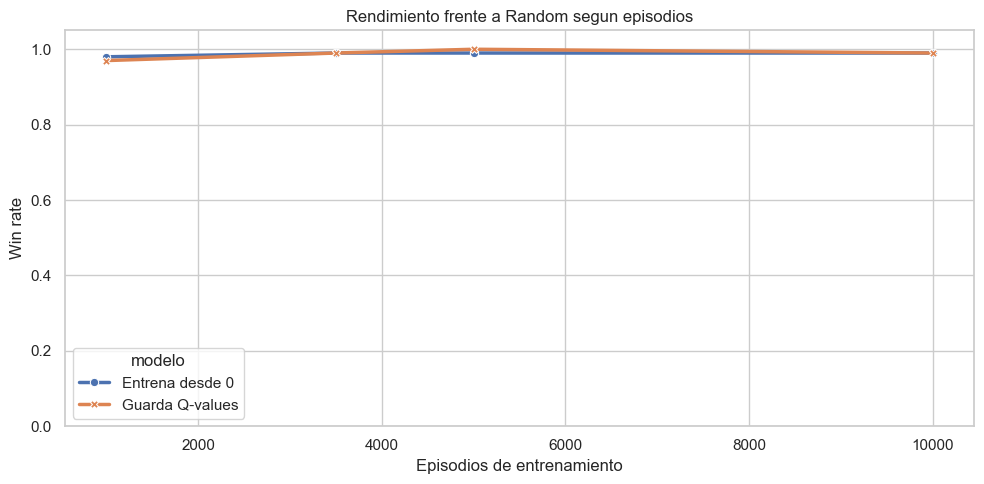

In [23]:
if not memory_df.empty:
    random_df = memory_df[memory_df["opponent"] == "Random"].copy().sort_values("episodes")
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=random_df,
        x="episodes",
        y="win_rate",
        hue="modelo",
        style="modelo",
        markers=True,
        dashes=False,
        linewidth=2.5,
    )
    plt.title("Rendimiento frente a Random segun episodios")
    plt.xlabel("Episodios de entrenamiento")
    plt.ylabel("Win rate")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Grafica omitida porque no existe q_memory_comparison.csv")


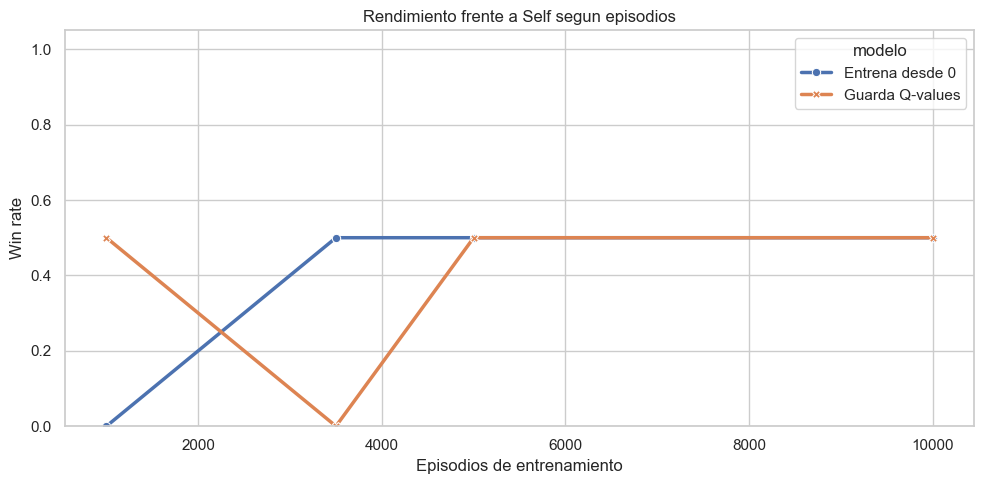

In [24]:
if not memory_df.empty:
    self_df = memory_df[memory_df["opponent"] == "Self"].copy().sort_values("episodes")
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=self_df,
        x="episodes",
        y="win_rate",
        hue="modelo",
        style="modelo",
        markers=True,
        dashes=False,
        linewidth=2.5,
    )
    plt.title("Rendimiento frente a Self segun episodios")
    plt.xlabel("Episodios de entrenamiento")
    plt.ylabel("Win rate")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Grafica omitida porque no existe q_memory_comparison.csv")


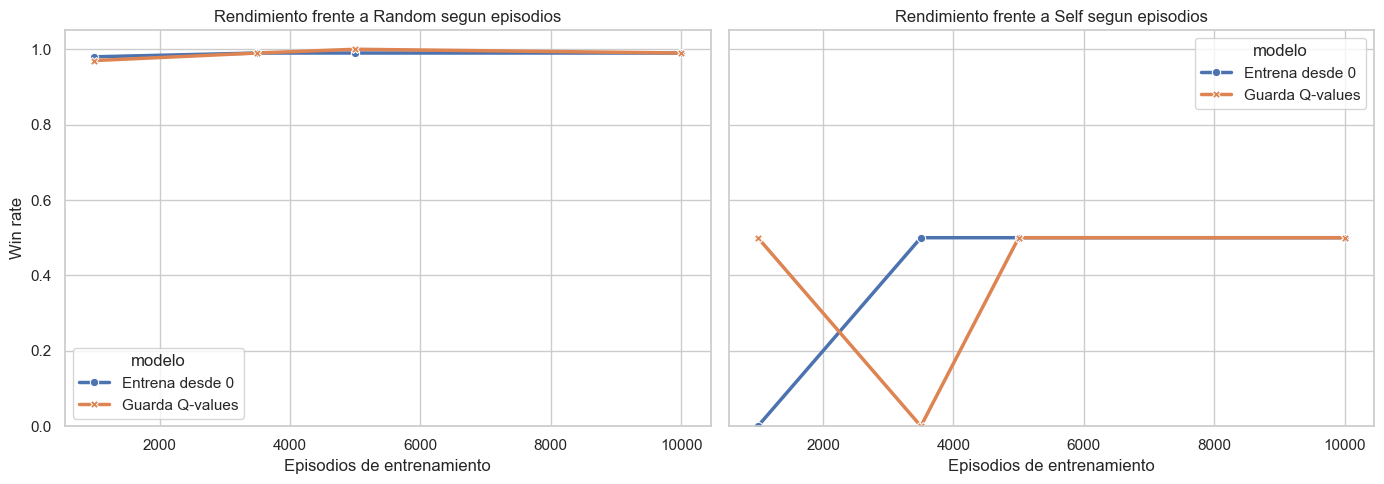

In [25]:
if not memory_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, opponent in zip(axes, ["Random", "Self"]):
        subset = memory_df[memory_df["opponent"] == opponent].copy().sort_values("episodes")
        sns.lineplot(
            data=subset,
            x="episodes",
            y="win_rate",
            hue="modelo",
            style="modelo",
            markers=True,
            dashes=False,
            linewidth=2.5,
            ax=ax,
        )
        ax.set_title(f"Rendimiento frente a {opponent} segun episodios")
        ax.set_xlabel("Episodios de entrenamiento")
        ax.set_ylabel("Win rate")
        ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Grafica omitida porque no existe q_memory_comparison.csv")


## 4. Conclusiones cortas

Guia para interpretar:
- si contra `Random` casi todas las configuraciones estan cerca de `1.0`, entonces el agente ya aprendio a derrotar bien a un rival simple,
- si contra `Self` cambia mucho el `draw_rate`, eso indica que la policy cambia su estabilidad o conservadurismo,
- si la linea `Guarda Q-values` queda por encima o igual a `Entrena desde 0`, entonces guardar memoria ayuda o al menos evita perder lo ya aprendido.
